GSINDy: ✓
System: Lorenz attractor  ẋ=σ(y-x), ẏ=x(ρ-z)-y, ż=xy-βz
Data: (2000, 3)   t_test: 1001 pts

Fitting SINDy...
Fitting WSINDy...
Fitting GS-SINDy...

All fits complete.

Method            Traj L2   Coef L2    Prec     Rec   Time(s)
--------------------------------------------------------------------
SINDy              0.4777    0.0001   1.000   1.000     0.203
WSINDy             0.0001    0.0000   1.000   1.000     0.622
GS-SINDy           0.0225    0.0000   1.000   1.000    29.672


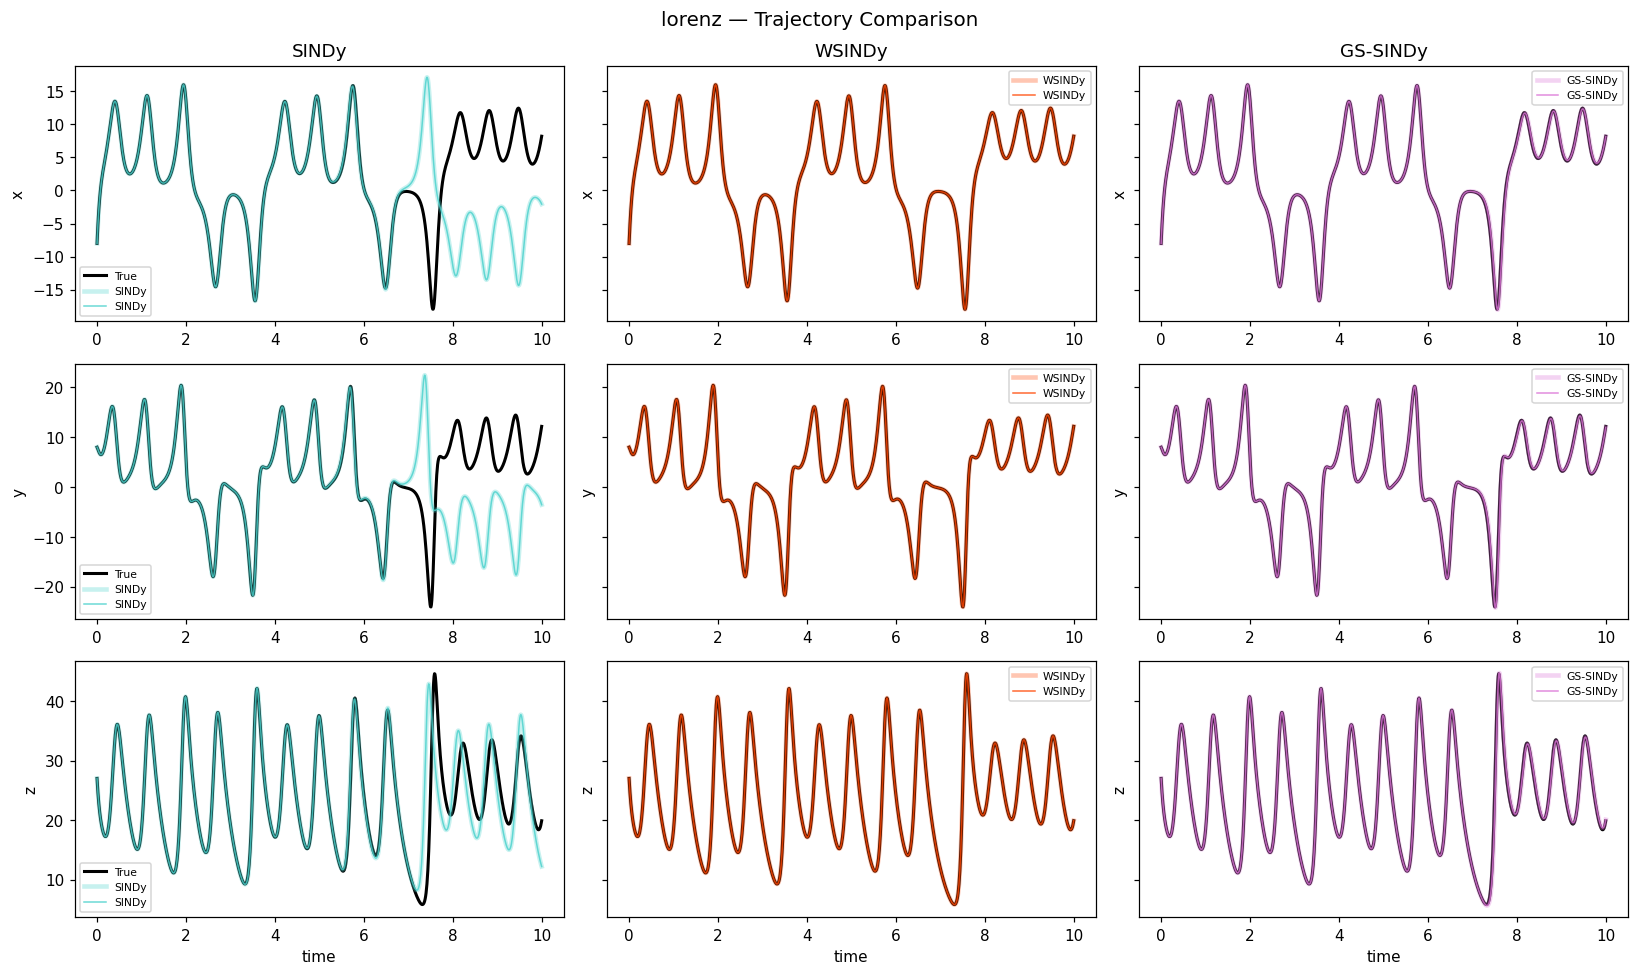

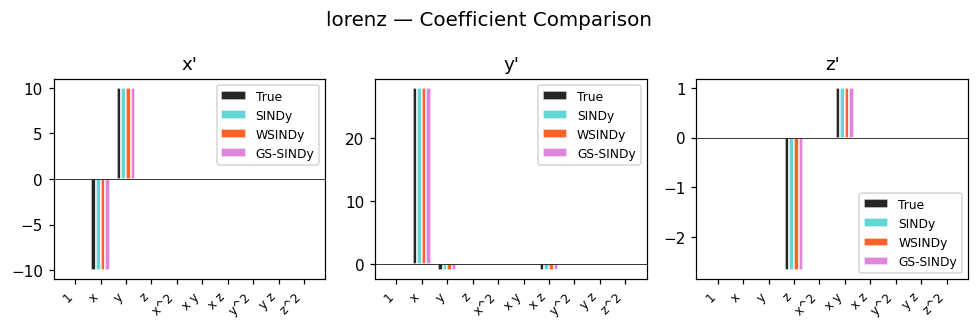

L2 Error (1st Initial Condition)
  noise = 0.00  

In [ ]:
# =============================================================================
# 00_Main_Comparison.py
# Fits SINDy, WSINDy, and GS-SINDy on any registered ODESystem and
# produces a unified comparison: table, trajectory plots, coefficient
# bar chart, and noise-sweep robustness curves.
#
# Set RUN_INLINE = True  to refit everything here.
# Set RUN_INLINE = False to load pre-saved .pkl files from the results/
# folder (faster after you have already run the three individual scripts).
# =============================================================================

# %% ── USER PARAMETERS ────────────────────────────────────────────────────────
import importlib
import wsindy_core
import ode_utils
import ode_systems
importlib.reload(wsindy_core)
importlib.reload(ode_utils)
importlib.reload(ode_systems)
from wsindy_core import WSINDy

import sys, os
sys.path.insert(0, os.getcwd())
from ode_systems import SYSTEMS, list_systems

# System
SYSTEM_KEY = "lorenz"
SYSTEM     = SYSTEMS[SYSTEM_KEY]

# Whether to refit (True) or load saved .pkl files (False)
# n=Needs sindy_SYSTEM KEY_results.pkl, wsindy_SYSTEM KEY_results.pkl, gsindy_SYSTEM KEY_results.pkl
RUN_INLINE = True

# Initial conditions
X0      = [-8.0, 8.0, 27.0]          # single IC for SINDy / WSINDy
X0_LIST = [                           # multiple ICs for GS-SINDy
    [-8.0,  8.0, 27.0],
    [ 0.0,  1.0, 20.0],
    [ 5.0, -5.0, 10.0],
]

# Integration
T_SPAN     = (0.0, 20.0)
DT         = 0.01
T_EVAL_END = 10.0
SEED       = 42

# Noise sweep
NOISE_LEVELS = [0.0, 0.01, 0.05, 0.1, 0.2]

# ── Per-method hyperparameters ────────────────────────────────────────────────

SINDY_CFG = dict(
    threshold=0.05,
    alpha=0.05,
    poly_degree=2,
    spline_s=1e-3,
)
WSINDY_CFG = dict(
    poly_degree=3,
    ld=0.05,
    gamma=1e-8,
    L=30,
    overlap=0.5,
)
GSINDY_CFG = dict(
    poly_degree=2,
    threshold_sindy=0.05,
    threshold_group=0.01,
    threshold_similarity=0.1,
    alpha=0.05,
    num_series=60,
    window_per=0.7,
    remove_per=0.2,
    deriv_spline=True,
)

RESULTS_DIR = '/Users/Chiara/Documents/Documents_Chiara_MacBook_Air/Education : Personal Projects : Studies/Data Driven Modeling/Orbital System/Results'

# %% ── IMPORTS ─────────────────────────────────────────────────────────────────

import pickle, time, warnings
from itertools import combinations_with_replacement
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 110

import pysindy as ps
from pysindy.differentiation import SINDyDerivative

from wsindy_core import WSINDy
from ode_utils import (
    generate_data, generate_multiple_trajectories, simulate_from_coefficients,
    plot_noise_sweep, relative_l2_error, coefficient_error, precision_recall,
    build_true_coef_matrix, print_discovered_equations,
)

os.makedirs(RESULTS_DIR, exist_ok=True)

# GS-SINDy availability
GSINDY_PATH = os.path.join(os.getcwd(), "GS-SINDy", "GSINDy")
if os.path.isdir(GSINDY_PATH):
    sys.path.insert(0, GSINDY_PATH)
    sys.path.insert(0, os.path.join(os.getcwd(), "GS-SINDy"))
try:
    from GSINDy import GSINDy
    GSINDY_AVAILABLE = True
    print("GSINDy: ✓")
except ImportError:
    GSINDY_AVAILABLE = False
    print("GSINDy: ✗ (fallback)")

print(f"System: {SYSTEM.description}")

# %% ── COMMON DATA ────────────────────────────────────────────────────────────

t, X = generate_data(SYSTEM, X0, T_SPAN, DT, noise_level=0.0, seed=SEED)
t_test = t[t <= T_EVAL_END]
X_test = X[:len(t_test)]
print(f"Data: {X.shape}   t_test: {len(t_test)} pts")

# %% ── FITTER HELPERS ─────────────────────────────────────────────────────────

def fit_sindy(X_data, cfg):
    diff = SINDyDerivative(kind="spline", s=cfg.get("spline_s", 1e-3))
    lib  = ps.PolynomialLibrary(degree=cfg["poly_degree"])
    m    = ps.SINDy(
        feature_library=lib,
        optimizer=ps.STLSQ(threshold=cfg["threshold"],
                            alpha=cfg["alpha"], max_iter=20),
        differentiation_method=diff,
    )
    t0 = time.time(); m.fit(X_data, t=DT, feature_names=SYSTEM.var_names)
    return m.coefficients(), m.get_feature_names(), time.time() - t0


def fit_wsindy(X_data, cfg):
    m = WSINDy(polys=np.arange(0, cfg["poly_degree"] + 1),
               ld=cfg["ld"], gamma=cfg["gamma"])
    t0 = time.time()
    m.fit_uniform(X_data, t, L=cfg["L"], overlap=cfg["overlap"])
    return m, m.get_coefficients(), m.get_feature_names(), time.time() - t0


def _make_gsindy_basis(d, deg):
    fns, nms = [], []
    for degree in range(deg + 1):
        for combo in combinations_with_replacement(range(d), degree):
            pw = [0] * d
            for idx in combo:
                pw[idx] += 1
            pows = tuple(pw)
            fns.append(
                lambda *args, p=pows: np.prod([a**pi for a, pi in zip(args, p)])
            )
            term = "".join(
                "" if pi == 0 else
                (SYSTEM.var_names[i] if pi == 1
                 else f"{SYSTEM.var_names[i]}^{pi}")
                for i, pi in enumerate(pows)
            )
            nms.append(term or "1")
    return {"functions": [np.array(fns)] * d,
            "names":     [np.array(nms)]  * d}


def fit_gsindy(X_list_data, cfg):
    d = SYSTEM.n_dim
    if GSINDY_AVAILABLE:
        basis = _make_gsindy_basis(d, cfg["poly_degree"])
        g = GSINDy(
            basis=basis, num_traj=len(X_list_data), num_feature=d,
            threshold_sindy=cfg["threshold_sindy"],
            threshold_group=cfg["threshold_group"],
            threshold_similarity=cfg["threshold_similarity"],
            alpha=cfg["alpha"], deriv_spline=cfg["deriv_spline"],
            max_iter=20, optimizer="SQTL", ensemble=False,
        )
        t0 = time.time()
        if d == 2:
            g.get_multi_sub_series_2D(X_list_data, t,
                                       num_series=cfg["num_series"],
                                       window_per=cfg["window_per"])
        else:
            g.get_multi_sub_series_3D(X_list_data, t,
                                       num_series=cfg["num_series"],
                                       window_per=cfg["window_per"])
        g.basis_identification(remove_per=cfg["remove_per"], plot_dist=False)
        Xi = g.prediction(X_list_data, t, split_basis=True)
        nms = list(basis["names"][0])
        return Xi.mean(axis=0), nms, time.time() - t0
    else:
        lib = ps.PolynomialLibrary(degree=cfg["poly_degree"])
        cl, fn_ref = [], None
        t0 = time.time()
        for Xi in X_list_data:
            m = ps.SINDy(feature_library=lib,
                         optimizer=ps.STLSQ(threshold=cfg["threshold_sindy"],
                                             alpha=cfg["alpha"]))
            m.fit(Xi, t=DT, feature_names=SYSTEM.var_names); cl.append(m.coefficients())
            fn_ref = m.get_feature_names()
        return np.mean(cl, axis=0), fn_ref, time.time() - t0


def safe_simulate(coef, poly_degree, x0, t_eval):
    lib = ps.PolynomialLibrary(degree=poly_degree); lib.fit(X)
    ff  = lambda x: lib.transform(np.array(x).reshape(1, -1))[0]
    try:
        return simulate_from_coefficients(coef, ff, x0, t_eval)
    except Exception:
        return np.full((len(t_eval), SYSTEM.n_dim), np.nan)

# %% ── FIT OR LOAD ────────────────────────────────────────────────────────────

if RUN_INLINE:
    print("\nFitting SINDy...")
    sc, sfn, st = fit_sindy(X, SINDY_CFG)

    print("Fitting WSINDy...")
    wm, wc, wfn, wt = fit_wsindy(X, WSINDY_CFG)
    # wc_model = WSINDy(polys=np.arange(0, WSINDY_CFG["poly_degree"]+1),
    #               ld=WSINDY_CFG["ld"], gamma=WSINDY_CFG["gamma"])
    # wc_model.fit_uniform(X, t, L=WSINDY_CFG["L"], overlap=WSINDY_CFG["overlap"])
    # wc_model.debug()
    # print("tags (each row = exponents [x,y,z] for that feature):")
    # for i, (name, tag) in enumerate(zip(wc_model.feature_names_, wc_model.tags)):
    #     print(f"  {i:2d}  {name:8s}  {tag}")

    print("Fitting GS-SINDy...")
    _, X_list_gs = generate_multiple_trajectories(
        SYSTEM, X0_LIST, T_SPAN, DT, noise_level=0.0, seed=SEED)
    gc, gfn, gt = fit_gsindy(X_list_gs, GSINDY_CFG)

else:
    for fpath, cv, fv, tv in [
        (f"{RESULTS_DIR}/sindy_{SYSTEM_KEY}_results.pkl",  "sc", "sfn", "st"),
        (f"{RESULTS_DIR}/wsindy_{SYSTEM_KEY}_results.pkl", "wc", "wfn", "wt"),
        (f"{RESULTS_DIR}/gsindy_{SYSTEM_KEY}_results.pkl", "gc", "gfn", "gt"),
    ]:
        with open(fpath, "rb") as fh:
            r = pickle.load(fh)
        globals()[cv] = r["coef"]
        globals()[fv] = r["feature_names"]
        globals()[tv] = r["fit_time"]

# Simulate
sp = safe_simulate(sc, SINDY_CFG["poly_degree"],  X0, t_test)
wp = wm.simulate(X0, (t_test[0], t_test[-1]), t_test)
gp = safe_simulate(gc, GSINDY_CFG["poly_degree"], X0, t_test)

print("\nAll fits complete.")

# %% ── SUMMARY TABLE ──────────────────────────────────────────────────────────

tc_s = build_true_coef_matrix(SYSTEM, sfn)
tc_w = build_true_coef_matrix(SYSTEM, wfn)
tc_g = build_true_coef_matrix(SYSTEM, gfn)

def row_metrics(c, tc, pred, time_):
    _, tot = relative_l2_error(X_test, pred)
    ce     = coefficient_error(tc.flatten(), c.flatten()) if tc is not None else float("nan")
    pr, re = (precision_recall(tc.flatten(), c.flatten())
               if tc is not None else (float("nan"), float("nan")))
    return tot, ce, pr, re, time_

rows = [
    ("SINDy",    *row_metrics(sc, tc_s, sp, st)),
    ("WSINDy",   *row_metrics(wc, tc_w, wp, wt)),
    ("GS-SINDy", *row_metrics(gc, tc_g, gp, gt)),
]

print("\n" + "=" * 68)
print(f"{'Method':<15}{'Traj L2':>10}{'Coef L2':>10}"
      f"{'Prec':>8}{'Rec':>8}{'Time(s)':>10}")
print("-" * 68)
for name, te, ce, pr, re, tt in rows:
    print(f"{name:<15}{te:>10.4f}{ce:>10.4f}{pr:>8.3f}{re:>8.3f}{tt:>10.3f}")
print("=" * 68)

# %% ── TRAJECTORY COMPARISON PLOT ────────────────────────────────────────────

n_dim  = SYSTEM.n_dim
colors = ["mediumturquoise", "orangered", "orchid"]
labels = ["SINDy", "WSINDy", "GS-SINDy"]
preds  = [sp, wp, gp]

fig, axes = plt.subplots(n_dim, 3, figsize=(5 * 3, 3 * n_dim), sharey="row")
if n_dim == 1:
    axes = axes[np.newaxis, :]

for col, (name, pred, color) in enumerate(zip(labels, preds, colors)):
    for row in range(n_dim):
        ax = axes[row, col]
        ax.plot(t_test, X_test[:, row], "k-", lw=2, label="True" if col == 0 else "")
        ax.plot(t_test, pred[:, row], "-", color=color, lw=3, label=name, alpha = 0.3)
        ax.plot(t_test, pred[:, row], "-", color=color, lw=1, label=name, alpha = 0.8)
        ax.set_ylabel(SYSTEM.var_names[row])
        ax.legend(fontsize=7)
        if row == 0:
            ax.set_title(name, fontsize=12)
    axes[-1, col].set_xlabel("time")

fig.suptitle(f"{SYSTEM_KEY} — Trajectory Comparison", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/{SYSTEM_KEY}_comparison_trajectories.png", dpi=150, facecolor="none", transparent= True)
plt.show()

# %% ── COEFFICIENT BAR CHART ──────────────────────────────────────────────────

# Use the SINDy feature set as the common reference frame
ref_names = sfn
tc_ref    = tc_s

def project_coef(c_in, names_in, names_out):
    c_out  = np.zeros((c_in.shape[0], len(names_out)))
    lo_out = [str(f).lower().replace(" ", "") for f in names_out]
    for j, nm in enumerate(names_in):
        key = str(nm).lower().replace(" ", "")
        if key in lo_out:
            c_out[:, lo_out.index(key)] = c_in[:, j]
    return c_out

sc_r = project_coef(sc, sfn, ref_names)
wc_r = project_coef(wc, wfn, ref_names)
gc_r = project_coef(gc, gfn, ref_names)

nr       = len(ref_names)
x        = np.arange(nr)
w_b      = 0.18
offsets  = [-1.5, -0.5, 0.5, 1.5]
bar_data = [("True",    tc_ref,   "black"),
             ("SINDy",    sc_r,   colors[0]),
             ("WSINDy",   wc_r,   colors[1]),
             ("GS-SINDy", gc_r,   colors[2])]

fig, axes = plt.subplots(1, n_dim, figsize = (9, 3))
if n_dim == 1:
    axes = [axes]
for eq_i, ax in enumerate(axes):
    for k, (name, c_arr, col) in enumerate(bar_data):
        if c_arr is None:
            continue
        ax.bar(x + offsets[k] * w_b, c_arr[eq_i], w_b, lw = 1,
               label=name, color=col, alpha=0.85,  edgecolor = "white")
    ax.set_xticks(x)
    ax.set_xticklabels(ref_names, rotation=45, ha="right", fontsize=8)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{SYSTEM.var_names[eq_i]}'")
    ax.legend(fontsize=8)

fig.suptitle(f"{SYSTEM_KEY} — Coefficient Comparison", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/{SYSTEM_KEY}_comparison_coefficients.png", dpi=150, facecolor="none", transparent= True)
plt.show()

# %% ── NOISE SWEEP ────────────────────────────────────────────────────────────

sweep_te = {"SINDy": [], "WSINDy": [], "GS-SINDy": []}

print("L2 Error (1st Initial Condition)\n", end = "  ")
for nl in NOISE_LEVELS:
    print(f"noise = {nl:.2f}", end = "  ")
    _, Xn = generate_data(SYSTEM, X0, T_SPAN, DT, noise_level=nl, seed=SEED)

    # SINDy
    try:
        c_s, fn_s, _ = fit_sindy(Xn, SINDY_CFG)
        Xp_s = safe_simulate(c_s, SINDY_CFG["poly_degree"], X0, t_test)
        _, te_s = relative_l2_error(X_test, Xp_s)
    except Exception:
        te_s = float("nan")
    sweep_te["SINDy"].append(te_s)

    # WSINDy — must use model's own simulate method
    try:
        wm_n, _, _, _ = fit_wsindy(Xn, WSINDY_CFG)
        Xp_w = wm_n.simulate(X0, (t_test[0], t_test[-1]), t_test)
        _, te_w = relative_l2_error(X_test, Xp_w)
    except Exception:
        te_w = float("nan")
    sweep_te["WSINDy"].append(te_w)

    # GS-SINDy
    try:
        _, Xl_n = generate_multiple_trajectories(
            SYSTEM, X0_LIST, T_SPAN, DT, noise_level=nl, seed=SEED)
        c_g, _, _ = fit_gsindy(Xl_n, GSINDY_CFG)
        Xp_g = safe_simulate(c_g, GSINDY_CFG["poly_degree"], X0, t_test)
        _, te_g = relative_l2_error(X_test, Xp_g)
    except Exception:
        te_g = float("nan")
    sweep_te["GS-SINDy"].append(te_g)

    print(f"S={te_s:.3f}  W={te_w:.3f}  G={te_g:.3f}")

fig = plot_noise_sweep(NOISE_LEVELS, sweep_te, metric="traj", title=f"{SYSTEM_KEY} — noise robustness")
plt.savefig(f"{RESULTS_DIR}/{SYSTEM_KEY}_comparison_noise.png", dpi=150, facecolor="none", transparent= True)
plt.show()

# %% ── SUMMARY BAR CHART ──────────────────────────────────────────────────────

metrics_labels = ["Traj L2", "Coef L2", "Precision", "Recall"]
bar_vals = {name: [te, ce, pr, re] for name, te, ce, pr, re, _ in rows}

fig, ax = plt.subplots(figsize=(6, 3))
x   = np.arange(len(metrics_labels))
w_b = 0.25
for i, (name, vals) in enumerate(bar_vals.items()):
    ax.bar(x + (i - 1) * w_b, vals, w_b, label=name, color=colors[i], alpha=0.85, edgecolor = "white")
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylabel("Value")
ax.set_title(f"{SYSTEM_KEY} — method summary", fontsize=13)
ax.legend(fontsize=11)
ax.axhline(0, color="k", lw=0.5)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/{SYSTEM_KEY}_comparison_bar.png", dpi=150, facecolor="none", transparent= True)
plt.show()

# Save summary
summary = dict(
    system=SYSTEM_KEY,
    methods=list(bar_vals.keys()),
    metrics=metrics_labels,
    values=bar_vals,
    noise_levels=NOISE_LEVELS,
    traj_errors=sweep_te,
)
with open(f"{RESULTS_DIR}/{SYSTEM_KEY}_comparison_summary.pkl", "wb") as fh:
    pickle.dump(summary, fh)
print(f"\nSummary saved → {RESULTS_DIR}/{SYSTEM_KEY}_comparison_summary.pkl")

In [ ]:
from scipy.integrate import solve_ivp
import numpy as np

coef_T = wc_model.coef.T
tags   = wc_model.tags

def rhs(t, x):
    features = np.array([
        np.prod([x[j] ** tags[i, j] for j in range(len(x))])
        for i in range(len(tags))
    ])
    return coef_T @ features

# Test the RHS at the initial condition
x0 = np.array([-8.0, 8.0, 27.0])
print("RHS at x0:", rhs(0, x0))
print("Expected : [180., -244., -135.11...]")

# Try integrating just a tiny bit
sol = solve_ivp(rhs, (0, 0.1), x0, method="RK45", rtol=1e-8, atol=1e-10)
print("Short integration success:", sol.success)
print("Final state:", sol.y[:, -1])

# Try the full window
sol2 = solve_ivp(rhs, (0, 10.0), x0, method="RK45", rtol=1e-8, atol=1e-10)
print("Full integration success:", sol2.success)
print("Message:", sol2.message)
print("Stopped at t =", sol2.t[-1])

RHS at x0: [ 160.          -16.00000001 -136.        ]
Expected : [180., -244., -135.11...]
Short integration success: True
Final state: [ 1.41377565  6.53995062 19.2271599 ]
Full integration success: True
Message: The solver successfully reached the end of the integration interval.
Stopped at t = 10.0


In [ ]:
print("coef_T shape:", coef_T.shape)
print("features at x0:")
features = np.array([
    np.prod([x0[j] ** tags[i, j] for j in range(3)])
    for i in range(len(tags))
])
print(features)
print()
print("eq0 (should be x_dot = 10y - 10x = 10*8 - 10*(-8) = 160):")
print("  got:", coef_T[0] @ features)
print("eq1 (should be y_dot = 28x - y - xz = 28*(-8) - 8 - (-8*27) = -224 - 8 + 216 = -16):")  
print("  got:", coef_T[1] @ features)
print("eq2 (should be z_dot = xy - (8/3)z = (-8*8) - (8/3)*27 = -64 - 72 = -136):")
print("  got:", coef_T[2] @ features)
t_test = t[t <= 10.0]
X_true_test = X[:len(t_test)]
X_pred_w = wc_model.simulate([-8.0, 8.0, 27.0], (t_test[0], t_test[-1]), t_test)
print("X_pred_w shape:", X_pred_w.shape)
print("Any nan?", np.any(np.isnan(X_pred_w)))
print("Any inf?", np.any(np.isinf(X_pred_w)))

from ode_utils import relative_l2_error
per_dim, total = relative_l2_error(X_true_test, X_pred_w)
print("per_dim errors:", per_dim)
print("total error:", total)

coef_T shape: (3, 20)
features at x0:
[ 1.0000e+00  2.7000e+01  8.0000e+00 -8.0000e+00  7.2900e+02  2.1600e+02
  6.4000e+01 -2.1600e+02 -6.4000e+01  6.4000e+01  1.9683e+04  5.8320e+03
  1.7280e+03  5.1200e+02 -5.8320e+03 -1.7280e+03 -5.1200e+02  1.7280e+03
  5.1200e+02 -5.1200e+02]

eq0 (should be x_dot = 10y - 10x = 10*8 - 10*(-8) = 160):
  got: 160.00000000134693
eq1 (should be y_dot = 28x - y - xz = 28*(-8) - 8 - (-8*27) = -224 - 8 + 216 = -16):
  got: -16.000000006682775
eq2 (should be z_dot = xy - (8/3)z = (-8*8) - (8/3)*27 = -64 - 72 = -136):
  got: -136.0000000011689
X_pred_w shape: (1001, 3)
Any nan? False
Any inf? False
per_dim errors: [0.00018564 0.00026062 0.00011008]
total error: 0.00014072246002260266
